In [1]:
!pip install flappy_bird_gymnasium pyyaml pyvirtualdisplay -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 46.1 MB/s eta 0:00:00:00:0100:01


![](https://github.com/markub3327/flappy-bird-gymnasium/blob/main/imgs/dqn.gif?raw=true)

## State

1. the last pipe's horizontal position
2. the last top pipe's vertical position
3. the last bottom pipe's vertical position
4. the next pipe's horizontal position
5. the next top pipe's vertical position
6. the next bottom pipe's vertical position
7. the next next pipe's horizontal position
8. the next next top pipe's vertical position
9. the next next bottom pipe's vertical position
10. player's vertical position
11. player's vertical velocity
12. player's rotation


## Action space

* 0 - do nothing
* 1 - flap


## Rewards

* +0.1 - every frame it stays alive
* +1.0 - successfully passing a pipe
* -1.0 - dying
* −0.5 - touch the top of the screen


# Implementation Steps
0. Set Env
1. Define DQN
2. Create the Experience Replay
3. Multiple episodes DQN train $\rightarrow$ setup
4. Epsilon-greedy policy + hyperparams 
   * *(epsilon decay)*
7. Target Network
8. Train & Test

---

### Epsilon ($\epsilon$) Decay Flow
$\epsilon = 1$  (explore more in the beginning)
$\downarrow$  
$0.9$  
$\downarrow$  
$0.8$  
$\downarrow$  
$0.7$  
$\vdots$  
$\downarrow$  
$0.05$ (explore less exploit more in the end)

---


### run()
- Train
- Test & visualize/render

# 1. Define DQN

In [2]:
%%writefile dqn.py

import torch
import torch.nn as nn

class DQN(nn.Module):
    # input dim, output dim, hidden dim
    def __init__(self, state_dim=12, action_dim=2, hidden_dim=256):
        super(DQN, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
        
    def forward(self, x):
        return self.model(x)

Writing dqn.py


# 2. Create the Experience Replay

In [3]:
%%writefile experience_replay.py

from collections import deque
import random

class ReplayMemory():
    def __init__(self, maxlen, seed=None):
        self.memory = deque([], maxlen=maxlen)  # ← deque not dequeue

    def append(self, new_exp):
        self.memory.append(new_exp)

    def sample(self, sample_size):
        return random.sample(self.memory, sample_size)

    def __len__(self):
        return len(self.memory)

Writing experience_replay.py


In [4]:
%%writefile parameters.yaml
flappybirdv0:
  env_id: FlappyBird-v0
  epsilon_init: 1
  epsilon_min: 0.05
  epsilon_decay: 0.9995
  replay_memory_size: 10000
  mini_batch_size: 32
  network_sync_rate: 10
  alpha: 0.001
  gamma: 0.99
  reward_threshold: 1000

Writing parameters.yaml


# 3. Multiple episodes DQN train $\rightarrow$ setup
# 4. Epsilon-greedy policy + hyperparams 
# 5. Target Network & Optimizer

### Optimizer: 

**High-Level Steps:**
1. Target Network
2. Optimize() $\rightarrow$ target Q-value $\rightarrow$ loss $\rightarrow$ back prop

---

### `train our dqn` (The Optimize Step)

1. Get **experience** from our experience replay.
2. Compute the target Q-val ($y_{true}$)
   * $\downarrow$ *(computed using the **target network**)*
3. Compute $\hat{y}$ ($y_{pred}$) $\rightarrow$ *(computed using the **policy network**)*
4. Calculate **loss**
5. **Back prop** (Backpropagation)



In [5]:
%%writefile agent.py

import os
import gymnasium as gym
import flappy_bird_gymnasium
import torch
import torch.nn as nn
import torch.optim as optim
import random
import yaml
from dqn import DQN
from experience_replay import ReplayMemory

RUNS_DIR = "runs"
os.makedirs(RUNS_DIR, exist_ok=True)

class Agent:
    def __init__(self, param_set):
        self.param_set = param_set

    def run(self, is_training=True, render=False, num_episodes=None):

        with open("parameters.yaml", "r") as f:
            all_param_set = yaml.safe_load(f)
            params = all_param_set[self.param_set]

        self.alpha              = params["alpha"]
        self.gamma              = params["gamma"]
        self.epsilon_init       = params["epsilon_init"]
        self.epsilon_min        = params["epsilon_min"]
        self.epsilon_decay      = params["epsilon_decay"]
        self.replay_memory_size = params["replay_memory_size"]
        self.mini_batch_size    = params["mini_batch_size"]
        self.reward_threshold   = params["reward_threshold"]
        self.network_sync_rate  = params["network_sync_rate"]

        self.loss_fn   = nn.MSELoss()
        self.optimizer = None

        self.LOG_FILE   = os.path.join(RUNS_DIR, f"{self.param_set}.log")
        self.MODEL_FILE = os.path.join(RUNS_DIR, f"{self.param_set}.pt")

        env = gym.make("FlappyBird-v0", render_mode="rgb_array" if render else None)

        num_states  = env.observation_space.shape[0]
        num_actions = env.action_space.n

        policy_dqn = DQN(num_states, num_actions)

        if is_training:
            memory      = ReplayMemory(self.replay_memory_size)
            epsilon     = self.epsilon_init
            target_dqn  = DQN(num_states, num_actions)
            target_dqn.load_state_dict(policy_dqn.state_dict())
            steps       = 0
            self.optimizer = optim.Adam(policy_dqn.parameters(), lr=self.alpha)
            best_reward = float("-inf")

        else:
            # Load best saved model for testing
            policy_dqn.load_state_dict(torch.load(self.MODEL_FILE))
            policy_dqn.eval()
            epsilon = 0  # no exploration during test

        # num_episodes controls training length; test always runs 1 episode
        total_episodes = num_episodes if num_episodes is not None else self.num_episodes

        for episode in range(total_episodes):

            state, _ = env.reset()
            state    = torch.tensor(state, dtype=torch.float)

            episode_reward = 0.0
            terminated     = False

            while not terminated and episode_reward < self.reward_threshold:

                if is_training and random.random() < epsilon:
                    action = env.action_space.sample()
                    action = torch.tensor(action, dtype=torch.long)
                else:
                    with torch.no_grad():
                        action = policy_dqn(state.unsqueeze(dim=0)).squeeze().argmax()

                next_state, reward, terminated, _, _ = env.step(action.item())

                reward     = torch.tensor(reward,     dtype=torch.float)
                next_state = torch.tensor(next_state, dtype=torch.float)

                if is_training:
                    memory.append((state, action, next_state, reward, terminated))
                    steps += 1

                episode_reward += reward.item()
                state = next_state

            print(f"Episode {episode+1:>4} | Reward: {episode_reward:>8.2f} | Epsilon: {epsilon:.4f}")

            if is_training:
                epsilon = max(epsilon * self.epsilon_decay, self.epsilon_min)

                if episode_reward > best_reward:
                    log_msg = f"Best reward = {episode_reward:.2f} at episode {episode+1}"
                    print(log_msg)
                    with open(self.LOG_FILE, "a") as f:
                        f.write(log_msg + "\n")
                    torch.save(policy_dqn.state_dict(), self.MODEL_FILE)
                    best_reward = episode_reward

            if is_training and len(memory) > self.mini_batch_size:
                mini_batch = memory.sample(self.mini_batch_size)
                self.optimize(mini_batch, policy_dqn, target_dqn)

                if steps >= self.network_sync_rate:
                    target_dqn.load_state_dict(policy_dqn.state_dict())
                    steps = 0

        env.close()

    def optimize(self, mini_batch, policy_dqn, target_dqn):

        states, actions, next_states, rewards, terminations = zip(*mini_batch)

        states       = torch.stack(states)
        actions      = torch.stack(actions)
        next_states  = torch.stack(next_states)
        rewards      = torch.stack(rewards)
        terminations = torch.tensor(terminations, dtype=torch.float)

        with torch.no_grad():
            target_q = rewards + (1 - terminations) * self.gamma * \
                       target_dqn(next_states).max(dim=1)[0]

        current_q = policy_dqn(states) \
                        .gather(dim=1, index=actions.unsqueeze(dim=1)) \
                        .squeeze()

        loss = self.loss_fn(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

Writing agent.py


In [6]:
import os, gymnasium, torch, torch.nn as nn, torch.optim as optim
import itertools, random, yaml, flappy_bird_gymnasium
from dqn import DQN
from experience_replay import ReplayMemory
from agent import Agent
import warnings
warnings.filterwarnings("ignore")

dql = Agent(param_set="flappybirdv0")
print("Starting training...")
dql.run(is_training=True, render=False, num_episodes=10000)  # render=False is faster for training

Starting training...
Episode    1 | Reward:    -8.10 | Epsilon: 1.0000
Best reward = -8.10 at episode 1
Episode    2 | Reward:    -7.50 | Epsilon: 0.9995
Best reward = -7.50 at episode 2
Episode    3 | Reward:    -8.10 | Epsilon: 0.9990
Episode    4 | Reward:    -8.10 | Epsilon: 0.9985
Episode    5 | Reward:    -5.70 | Epsilon: 0.9980
Best reward = -5.70 at episode 5
Episode    6 | Reward:    -7.50 | Epsilon: 0.9975
Episode    7 | Reward:    -8.70 | Epsilon: 0.9970
Episode    8 | Reward:    -5.70 | Epsilon: 0.9965
Episode    9 | Reward:    -8.10 | Epsilon: 0.9960
Episode   10 | Reward:    -8.10 | Epsilon: 0.9955
Episode   11 | Reward:    -8.10 | Epsilon: 0.9950
Episode   12 | Reward:    -8.10 | Epsilon: 0.9945
Episode   13 | Reward:    -8.70 | Epsilon: 0.9940
Episode   14 | Reward:    -5.70 | Epsilon: 0.9935
Episode   15 | Reward:    -8.10 | Epsilon: 0.9930
Episode   16 | Reward:    -7.50 | Epsilon: 0.9925
Episode   17 | Reward:    -7.50 | Epsilon: 0.9920
Episode   18 | Reward:    -6.9

Test episode reward: 2.30 | Frames: 58


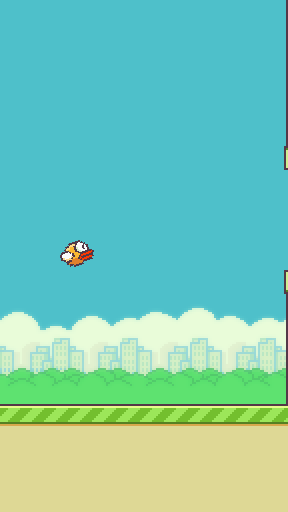

In [7]:
# ── Test & Save GIF ───────────────────────────────────────────────────
import sys, warnings
if 'agent' in sys.modules:
    del sys.modules['agent']
warnings.filterwarnings("ignore")

from pyvirtualdisplay import Display
from PIL import Image as PILImage
from IPython.display import display as ipy_display, Image
from agent import Agent
import gymnasium as gym
import flappy_bird_gymnasium
import torch
from dqn import DQN

# Virtual display
_display = Display(visible=0, size=(400, 600))
_display.start()

# Capture frames
env = gym.make("FlappyBird-v0", render_mode="rgb_array")
policy_dqn = DQN(env.observation_space.shape[0], env.action_space.n)
policy_dqn.load_state_dict(torch.load("runs/flappybirdv0.pt"))
policy_dqn.eval()

state, _ = env.reset()
state = torch.tensor(state, dtype=torch.float)
frames, terminated, episode_reward = [], False, 0.0

while not terminated:
    with torch.no_grad():
        action = policy_dqn(state.unsqueeze(0)).squeeze().argmax().item()
    state, reward, terminated, _, _ = env.step(action)
    state = torch.tensor(state, dtype=torch.float)
    episode_reward += reward
    frames.append(env.render())

env.close()
_display.stop()
print(f"Test episode reward: {episode_reward:.2f} | Frames: {len(frames)}")

# Save GIF
gif_path = "test_run.gif"
pil_frames = [PILImage.fromarray(f) for f in frames]
pil_frames[0].save(gif_path, format="GIF", save_all=True,
                   append_images=pil_frames[1:], duration=40, loop=0)

ipy_display(Image(data=open(gif_path, "rb").read()))